In [ ]:
# Ensure legacy keras is used to use BERT
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import re
from datasets import load_dataset
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from transformers import BertTokenizer
from scipy.stats import norm

ds = load_dataset('imdb')['train']

def check_char_frequency(regex, title_plot, data):
    word_counts = Counter(
        word.lower()
        for text in data
        for word in re.findall(regex, text)
    )

    # Remove common BERT special tokens if they appear in the counts
    for token in ['[pad]', '[cls]', '[sep]']:
        if token in word_counts:
            del word_counts[token]

    top_words = word_counts.most_common(20)

    labels, values = zip(*top_words)

    plt.figure(figsize=(12, 6))
    plt.bar(labels, values, color='skyblue', edgecolor='black')
    plt.xticks(rotation=45, ha='right')
    plt.title(title_plot)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

def check_int_frequency(regex, title_plot, data):
    cnt = Counter(num for sublist in data for num in sublist)
    global_frequencies = dict(cnt.most_common(20))

    plt.figure(figsize=(12, 6))
    plt.bar(list(global_frequencies.keys()), list(global_frequencies.values()), color='skyblue', edgecolor='black')
    plt.xticks(rotation=45, ha='right')
    plt.title(title_plot)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

def detokenize(example):
    return tokenizer.decode(example)

encoder_inputs = ds.map(tokenize, batched=True)
decoded = encoder_inputs.map(lambda example: {'decoded_text': detokenize(example['input_ids'])}, batched=False)
decoded

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'decoded_text'],
    num_rows: 25000
})

In [ ]:
def std_dev(texts):
  # Calc stddev
  char_lengths = [len(t) for t in texts]
  word_counts = [len(t.split()) for t in texts]
  mean_chars, std_chars = np.mean(char_lengths), np.std(char_lengths)
  mean_words, std_words = np.mean(word_counts), np.std(word_counts)

  print(f"Text Length (Chars): Mean = {mean_chars:.2f}, Std Dev = {std_chars:.2f}")
  print(f"Word Count: Mean = {mean_words:.2f}, Std Dev = {std_words:.2f}")

  # Generate points for smooth normal distribution curves
  x_chars = np.linspace(mean_chars - 4*std_chars, mean_chars + 4*std_chars, 100)
  p_chars = norm.pdf(x_chars, mean_chars, std_chars)

  x_words = np.linspace(mean_words - 4*std_words, mean_words + 4*std_words, 100)
  p_words = norm.pdf(x_words, mean_words, std_words)

  # Plot
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  axes[0].plot(x_chars, p_chars, color='blue', linewidth=2)
  axes[0].fill_between(x_chars, p_chars, alpha=0.3, color='blue')
  axes[0].set_title('Normal Distribution of Text Length')
  axes[0].set_xlabel('Number of Characters')
  axes[0].set_ylabel('Probability Density')
  axes[0].grid(True)

  axes[1].plot(x_words, p_words, color='green', linewidth=2)
  axes[1].fill_between(x_words, p_words, alpha=0.3, color='green')
  axes[1].set_title('Normal Distribution of Word Count')
  axes[1].set_xlabel('Number of Words')
  axes[1].set_ylabel('Probability Density')
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

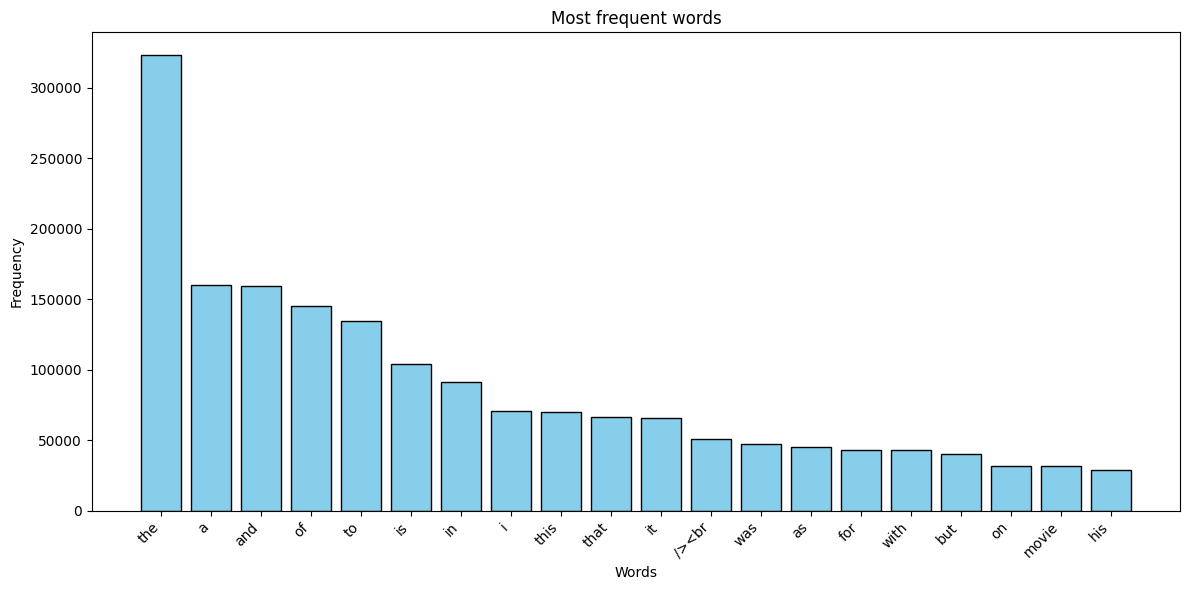

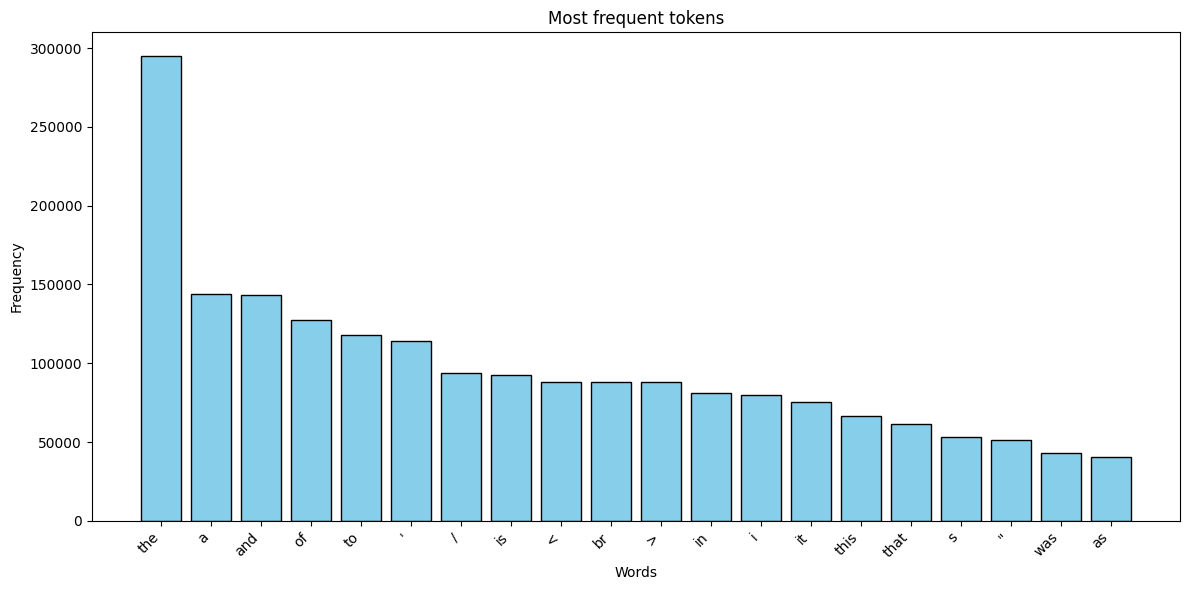

In [ ]:

check_char_frequency(r'[^\s-]+', 'Most frequent words', ds['text'])
check_char_frequency(r'[^\s-]+', 'Most frequent tokens', decoded['decoded_text'][1:])

Text Length (Chars): Mean = 1325.07, Std Dev = 1003.11
Word Count: Mean = 233.79, Std Dev = 173.73


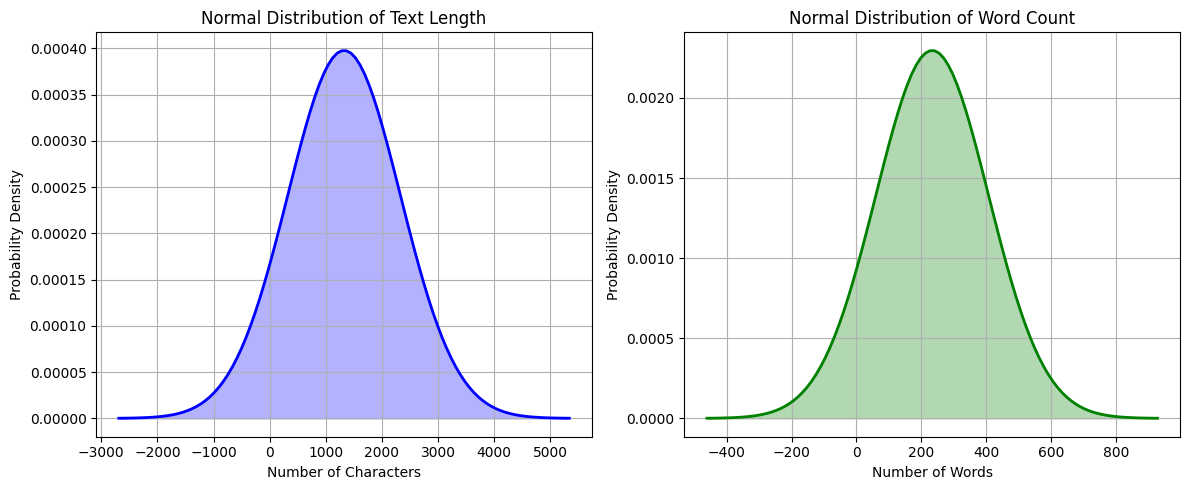

In [ ]:
std_dev(ds['text'])